In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('emails.csv')


In [3]:
df.sample(5)

,text,spam
3604,Subject: re : flat screens f . y . i . - - -...,0
4382,Subject: the 1999 form w - 2 and retiree tax f...,0
2990,Subject: meeting on the 20 th of march robert...,0
4890,Subject: kirstee ' s role in london vince : ...,0
4226,"Subject: re : tony hamilton chris , e hired ...",0


In [4]:
df.shape

(5728, 2)

DATA CLEANING

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 8.6 MB


In [6]:
df.rename(columns={'spam':'target'},inplace=True)
df.head()

,text,target
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [7]:

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [8]:
df['target'] = encoder.fit_transform(df['target'])

In [9]:
df.head()

,text,target
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [10]:
df.isnull().sum()

text      0
target    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(33)

In [12]:
df=df.drop_duplicates(keep='first')

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(5695, 2)

EDA

In [15]:
df['target'].value_counts()

target
0    4327
1    1368
Name: count, dtype: int64

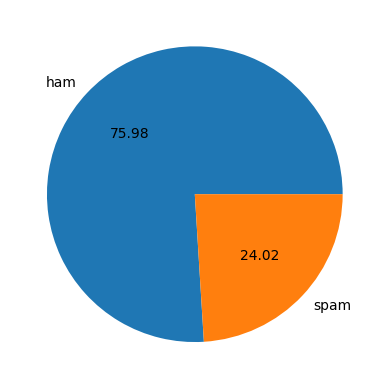

In [16]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [17]:
# Data is imbalanced
import nltk

In [18]:
!pip install nltk

zsh:1: command not found: pip


In [19]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/chandrakanthdodapaneni/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
df['num_characters'] = df['text'].apply(len)

In [21]:
df.head()

,text,target,num_characters
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235


In [22]:
target = df.pop('target')
df.insert(0, 'target', target)

df.head()

,target,text,num_characters
0,1,Subject: naturally irresistible your corporate...,1484
1,1,Subject: the stock trading gunslinger fanny i...,598
2,1,Subject: unbelievable new homes made easy im ...,448
3,1,Subject: 4 color printing special request add...,500
4,1,"Subject: do not have money , get software cds ...",235


In [23]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [24]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,1,Subject: naturally irresistible your corporate...,1484,325,11
1,1,Subject: the stock trading gunslinger fanny i...,598,90,1
2,1,Subject: unbelievable new homes made easy im ...,448,88,4
3,1,Subject: 4 color printing special request add...,500,99,5
4,1,"Subject: do not have money , get software cds ...",235,53,9


In [25]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5695.000000,5695.000000,5695.000000
mean,1558.067076,328.214047,19.462511
std,2047.078711,419.654234,35.981993
min,13.000000,3.000000,1.000000
25%,508.500000,102.000000,7.000000
50%,979.000000,211.000000,12.000000
75%,1893.000000,403.000000,22.000000
max,43952.000000,8479.000000,1565.000000


In [26]:
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4327.000000,4327.000000,4327.000000
mean,1634.200139,347.283799,19.838225
std,1965.016383,407.227757,38.124564
min,13.000000,3.000000,1.000000
25%,577.500000,120.000000,7.000000
50%,1122.000000,240.000000,13.000000
75%,2037.500000,440.500000,22.000000
max,43952.000000,8479.000000,1565.000000


In [27]:
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,1368.000000,1368.000000,1368.000000
mean,1317.257310,267.896199,18.274123
std,2271.372893,451.623124,28.130434
min,18.000000,5.000000,1.000000
25%,401.500000,80.000000,6.000000
50%,693.500000,141.000000,11.000000
75%,1250.250000,252.000000,18.000000
max,28432.000000,6131.000000,438.000000


In [28]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

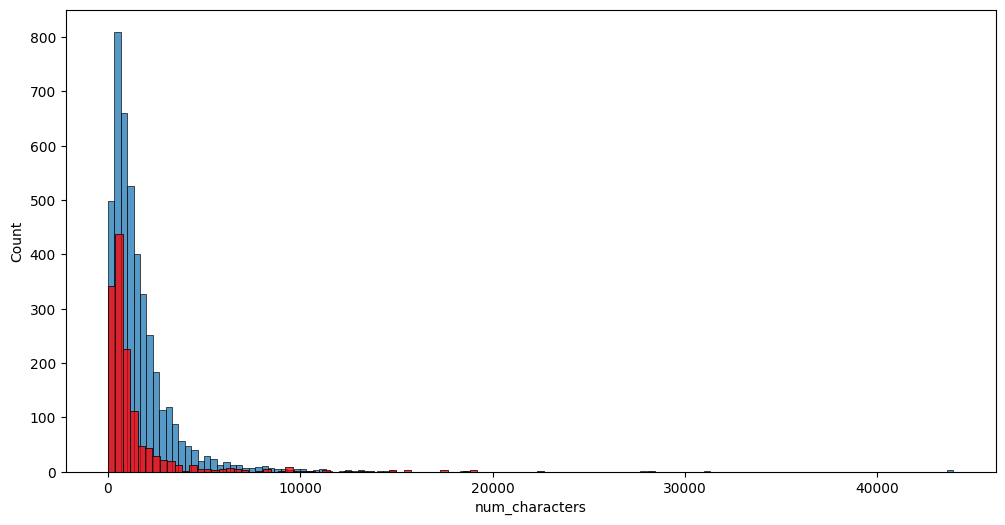

In [29]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

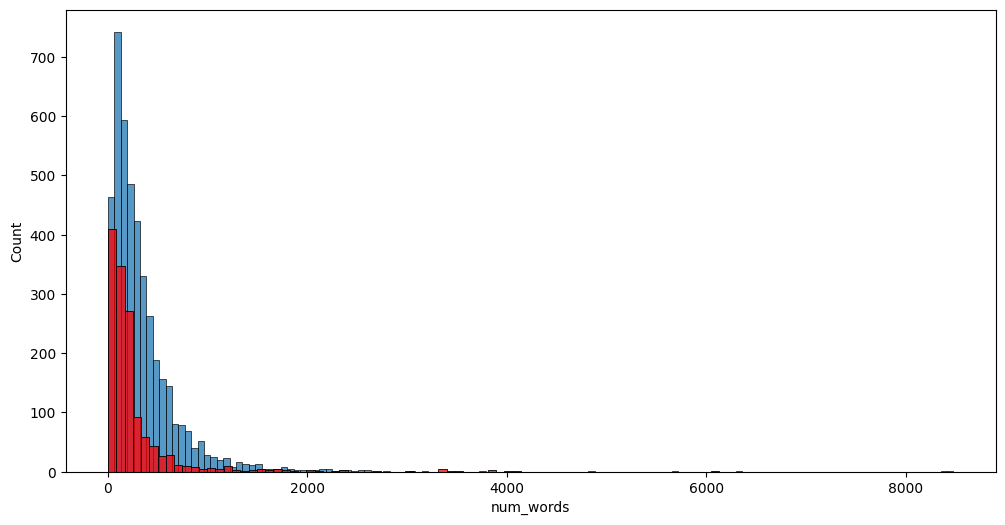

In [30]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

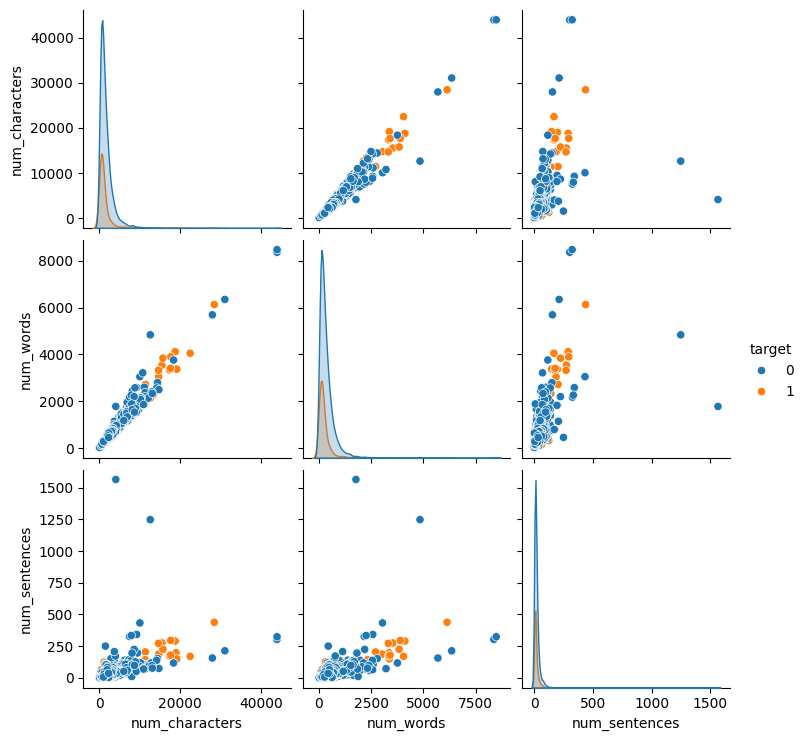

In [31]:
sns.pairplot(df,hue='target')



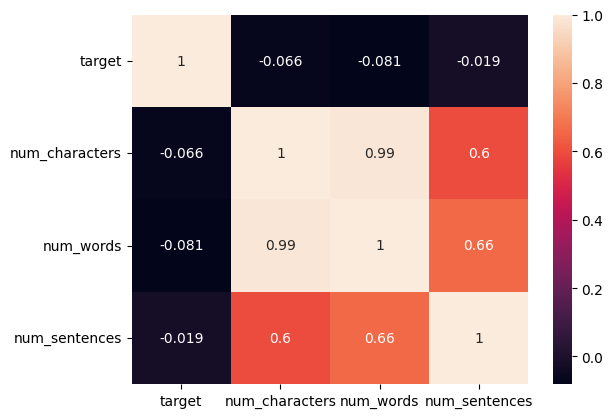

In [32]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

DATA CLEANING

In [33]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/chandrakanthdodapaneni/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [35]:
df['text'][10]

"Subject: las vegas high rise boom  las vegas is fast becoming a major metropolitan city ! 60 +  new high rise towers are expected to be built on and around the las vegas strip  within the next 3 - 4 years , that ' s 30 , 000 + condominiums !  this boom has just begun ! buy first . . . early phase ,  pre - construction pricing is now available on las vegas high rises including  trump , cosmopolitan , mgm , turnberry , icon , sky , among others .  join the interest list :  http : / / www . verticallv . com  message has been sent to you by realty one highrise . learn more at www . verticallv . comif you  wish to be excluded from future mailings , please reply with the word remove in  the subject line . "

In [36]:

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [37]:
df['transformed_text'] = df['text'].apply(transform_text)

In [38]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,1,Subject: naturally irresistible your corporate...,1484,325,11,subject natur irresist corpor ident lt realli ...
1,1,Subject: the stock trading gunslinger fanny i...,598,90,1,subject stock trade gunsling fanni merril muzo...
2,1,Subject: unbelievable new homes made easy im ...,448,88,4,subject unbeliev new home made easi im want sh...
3,1,Subject: 4 color printing special request add...,500,99,5,subject 4 color print special request addit in...
4,1,"Subject: do not have money , get software cds ...",235,53,9,subject money get softwar cd softwar compat gr...


In [39]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [40]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

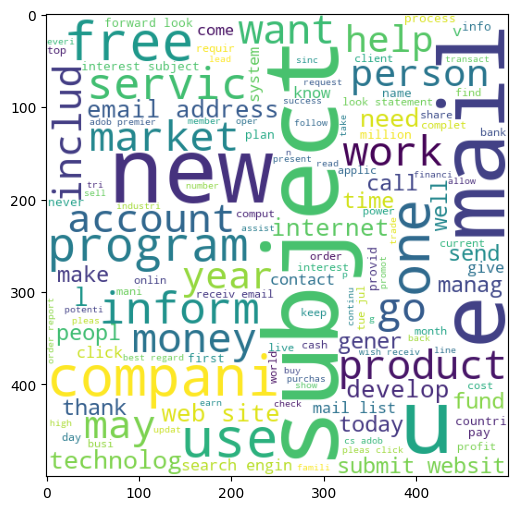

In [41]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [42]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

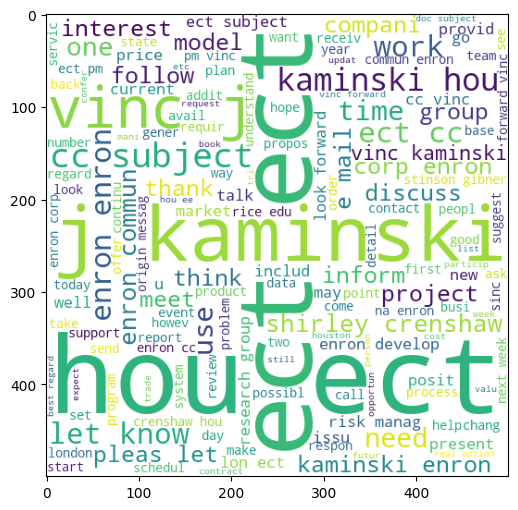

In [43]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [44]:

df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,1,Subject: naturally irresistible your corporate...,1484,325,11,subject natur irresist corpor ident lt realli ...
1,1,Subject: the stock trading gunslinger fanny i...,598,90,1,subject stock trade gunsling fanni merril muzo...
2,1,Subject: unbelievable new homes made easy im ...,448,88,4,subject unbeliev new home made easi im want sh...
3,1,Subject: 4 color printing special request add...,500,99,5,subject 4 color print special request addit in...
4,1,"Subject: do not have money , get software cds ...",235,53,9,subject money get softwar cd softwar compat gr...


In [45]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [46]:
len(spam_corpus)

174630

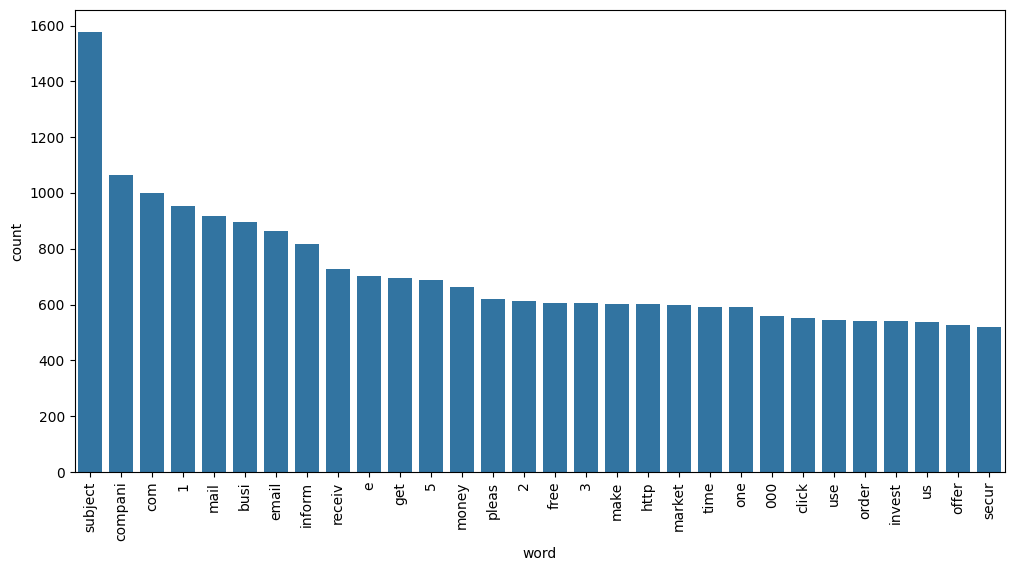

In [47]:
from collections import Counter

top_words = pd.DataFrame(
    Counter(spam_corpus).most_common(30),
    columns=['word', 'count']
)

plt.figure(figsize=(12,6))
sns.barplot(data=top_words, x='word', y='count')
plt.xticks(rotation=90)
plt.show()

In [48]:

ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [49]:
len(ham_corpus)

702991

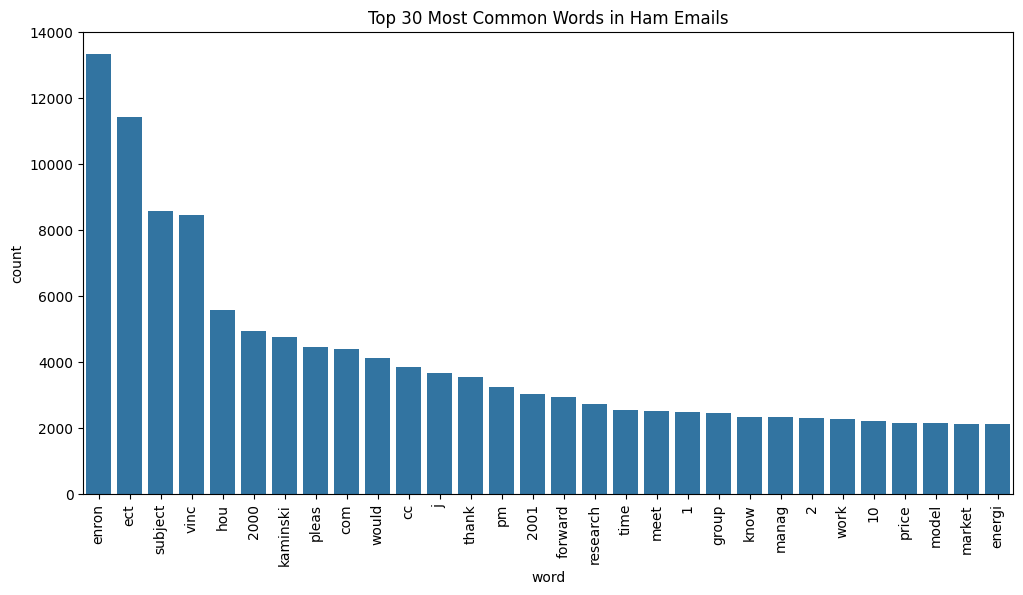

In [50]:

from collections import Counter

ham_words = pd.DataFrame(
    Counter(ham_corpus).most_common(30),
    columns=['word', 'count']
)

plt.figure(figsize=(12,6))
sns.barplot(data=ham_words, x='word', y='count')

plt.xticks(rotation=90)
plt.title("Top 30 Most Common Words in Ham Emails")
plt.show()

In [51]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,1,Subject: naturally irresistible your corporate...,1484,325,11,subject natur irresist corpor ident lt realli ...
1,1,Subject: the stock trading gunslinger fanny i...,598,90,1,subject stock trade gunsling fanni merril muzo...
2,1,Subject: unbelievable new homes made easy im ...,448,88,4,subject unbeliev new home made easi im want sh...
3,1,Subject: 4 color printing special request add...,500,99,5,subject 4 color print special request addit in...
4,1,"Subject: do not have money , get software cds ...",235,53,9,subject money get softwar cd softwar compat gr...


MODEL BUILDING


In [93]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)


In [94]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [95]:
y = df['target'].values

In [96]:
from sklearn.model_selection import train_test_split

In [97]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [98]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [99]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [100]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9596136962247586
[[836   7]
 [ 39 257]]
0.9734848484848485


In [101]:

mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9806848112379281
[[839   4]
 [ 18 278]]
0.9858156028368794


In [102]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9420544337137841
[[777  66]
 [  0 296]]
0.8176795580110497


BY ACCURACY AND PRECISION SCORE MND IS GOOD MODEL

In [62]:
pip install xgboost --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [64]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [65]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [66]:

def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision


In [67]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9920983318700615, 0.993127147766323)

In [68]:

accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9920983318700615
Precision -  0.993127147766323
For  KN
Accuracy -  0.9719051799824407
Precision -  0.9680851063829787
For  NB
Accuracy -  0.9806848112379281
Precision -  0.9858156028368794
For  DT
Accuracy -  0.9165935030728709
Precision -  0.7723577235772358
For  LR
Accuracy -  0.9771729587357331
Precision -  0.9655172413793104


/opt/homebrew/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9771729587357331
Precision -  0.9927007299270073
For  AdaBoost
Accuracy -  0.9490781387181738
Precision -  0.8695652173913043
For  BgC
Accuracy -  0.9648814749780509
Precision -  0.9324324324324325
For  ETC
Accuracy -  0.9798068481123793
Precision -  1.0
For  GBDT
Accuracy -  0.9569798068481123
Precision -  0.9591078066914498
For  xgb
Accuracy -  0.9824407374890255
Precision -  0.9630872483221476


In [69]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [70]:
performance_df

,Algorithm,Accuracy,Precision
8,ETC,0.979807,1.000000
0,SVC,0.992098,0.993127
5,RF,0.977173,0.992701
2,NB,0.980685,0.985816
1,KN,0.971905,0.968085
4,LR,0.977173,0.965517
10,xgb,0.982441,0.963087
9,GBDT,0.956980,0.959108
7,BgC,0.964881,0.932432
6,AdaBoost,0.949078,0.869565


In [71]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [72]:

performance_df1

,Algorithm,variable,value
0,ETC,Accuracy,0.979807
1,SVC,Accuracy,0.992098
2,RF,Accuracy,0.977173
3,NB,Accuracy,0.980685
4,KN,Accuracy,0.971905
5,LR,Accuracy,0.977173
6,xgb,Accuracy,0.982441
7,GBDT,Accuracy,0.956980
8,BgC,Accuracy,0.964881
9,AdaBoost,Accuracy,0.949078


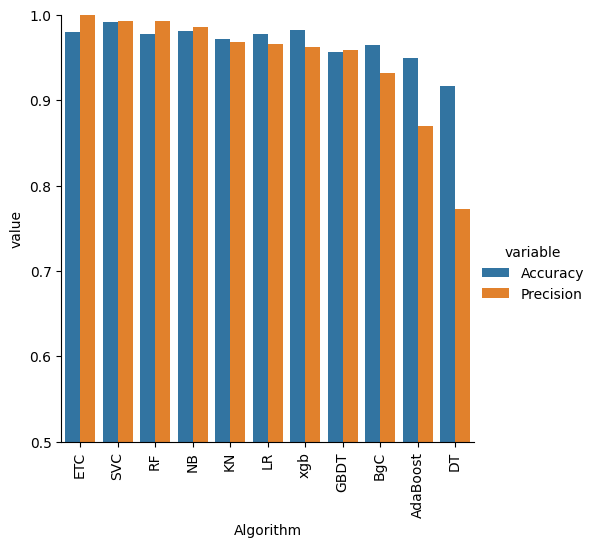

In [73]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [74]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [75]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [76]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [77]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [78]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [79]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,ETC,0.979807,1.000000,0.979807,1.000000,0.979807,1.000000,0.979807,1.000000
1,SVC,0.992098,0.993127,0.992098,0.993127,0.992098,0.993127,0.992098,0.993127
2,RF,0.977173,0.992701,0.977173,0.992701,0.977173,0.992701,0.977173,0.992701
3,NB,0.980685,0.985816,0.980685,0.985816,0.980685,0.985816,0.980685,0.985816
4,KN,0.971905,0.968085,0.971905,0.968085,0.971905,0.968085,0.971905,0.968085
5,LR,0.977173,0.965517,0.977173,0.965517,0.977173,0.965517,0.977173,0.965517
6,xgb,0.982441,0.963087,0.982441,0.963087,0.982441,0.963087,0.982441,0.963087
7,GBDT,0.956980,0.959108,0.956980,0.959108,0.956980,0.959108,0.956980,0.959108
8,BgC,0.964881,0.932432,0.964881,0.932432,0.964881,0.932432,0.964881,0.932432
9,AdaBoost,0.949078,0.869565,0.949078,0.869565,0.949078,0.869565,0.949078,0.869565


In [80]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [81]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [82]:
voting.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [83]:

y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.990342405618964
Precision 0.9896907216494846


In [84]:

# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [85]:
from sklearn.ensemble import StackingClassifier

In [86]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [87]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9938542581211589
Precision 0.9898305084745763


In [103]:
import pickle
pickle.dump(tfidf,open('vectorizer2.pkl','wb'))
pickle.dump(mnb,open('model2.pkl','wb'))